# Clonal Dynamics, Clonal Bias, Clonal Diversity, Some Visualizations for Single-Cell Objects

In [1]:
library(Seurat)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: ggplot2



In [2]:
getwd()

[1] "/home/rstudio/analysis"

In [3]:
setwd('/home/rstudio/analysis/saved_objects')

# Individual patients
patient3 <- readRDS("patient3.rds")
patient3_transform <- readRDS("patient3_transform.rds")
combined.TCR_p3 <- readRDS("combined_TCR_p3.rds")

patient4 <- readRDS("patient4.rds")
patient4_transform <- readRDS("patient4_transform.rds")
combined.TCR_p4 <- readRDS("combined_TCR_p4.rds")

# Merged & integrated data
merged_seurat <- readRDS("merged_seurat.rds")
combined.TCR_all <- readRDS("combined_TCR_all.rds")

# Combined Seurat + TCR objects
sce_patient3 <- readRDS("sce_patient3.rds")
sce_patient4 <- readRDS("sce_patient4.rds")
sce_all_patients_new <- readRDS("sce_all_patients_new.rds")

In [4]:
sce_all_patients <- readRDS("sce_all_patients.rds")

In [5]:
setwd('/home/rstudio/analysis/')
getwd()

[1] "/home/rstudio/analysis"

## Clonal Dynamics - clonalHomeostasis, clonalProportion

### Patient 3

### todo - add note here

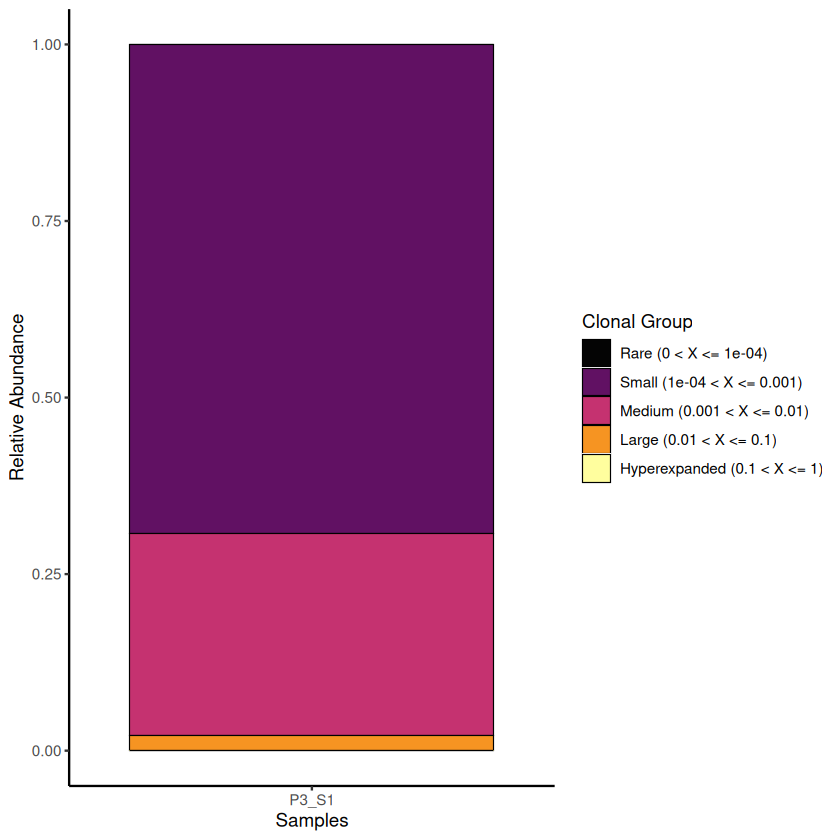

In [6]:
#clonalHomeostasis
## distribution of TCR or BCR clones into frequency bins
clonalHomeostasis(combined.TCR_p3, 
                  cloneCall = "gene")

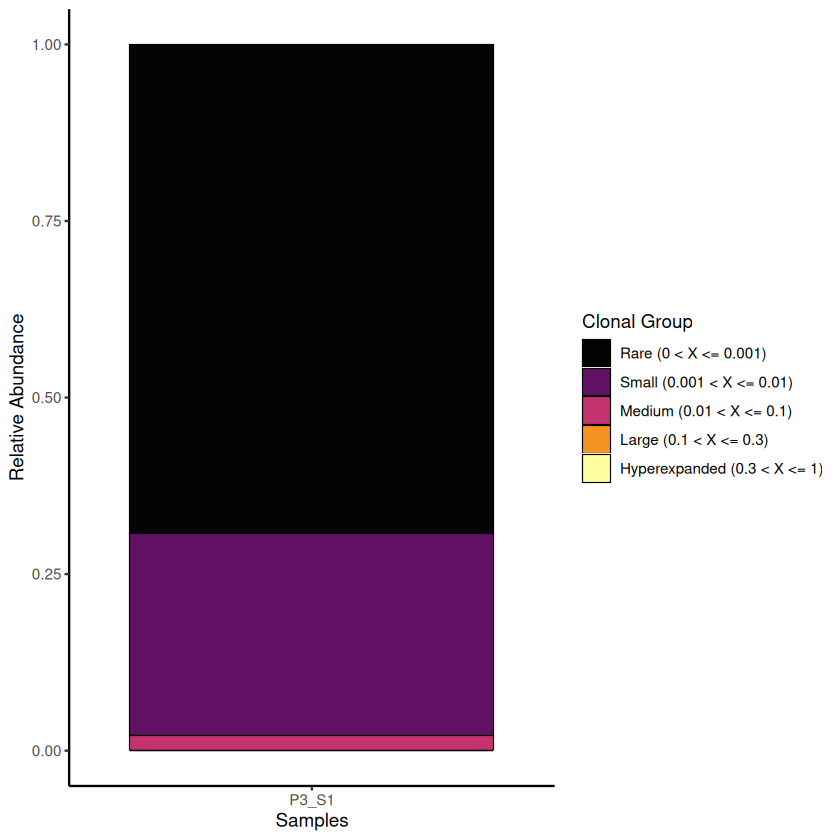

In [7]:
clonalHomeostasis(combined.TCR_p3, 
                  cloneCall = "gene",
                  cloneSize = c(Rare = 0.001, Small = 0.01, Medium = 0.1, Large = 0.3, Hyperexpanded =
    1))

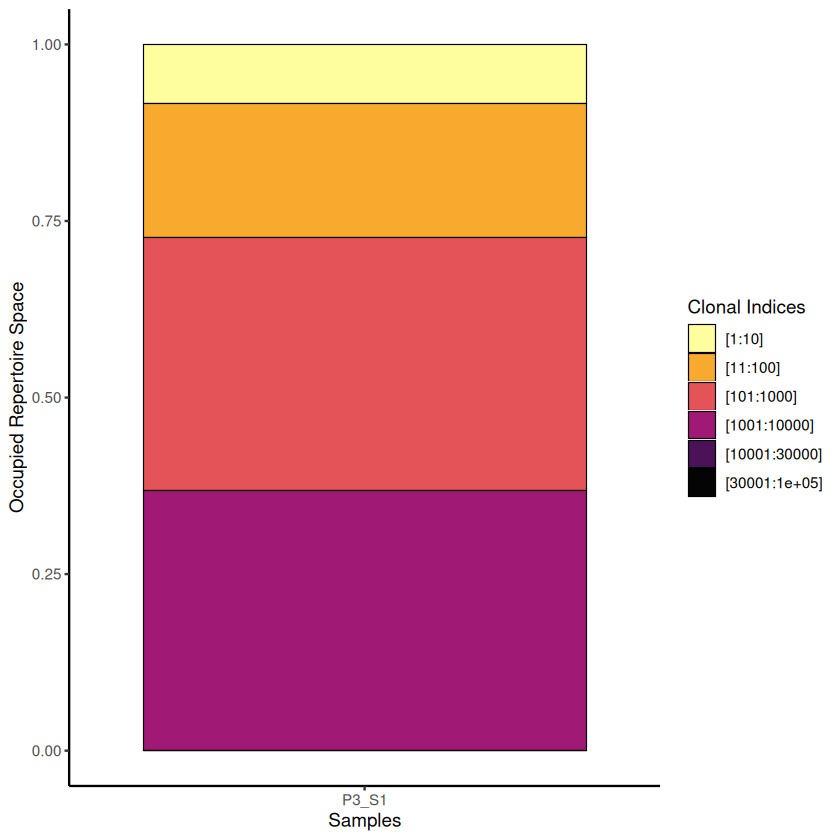

In [8]:
clonalProportion(combined.TCR_p3, 
                 cloneCall = "gene") 

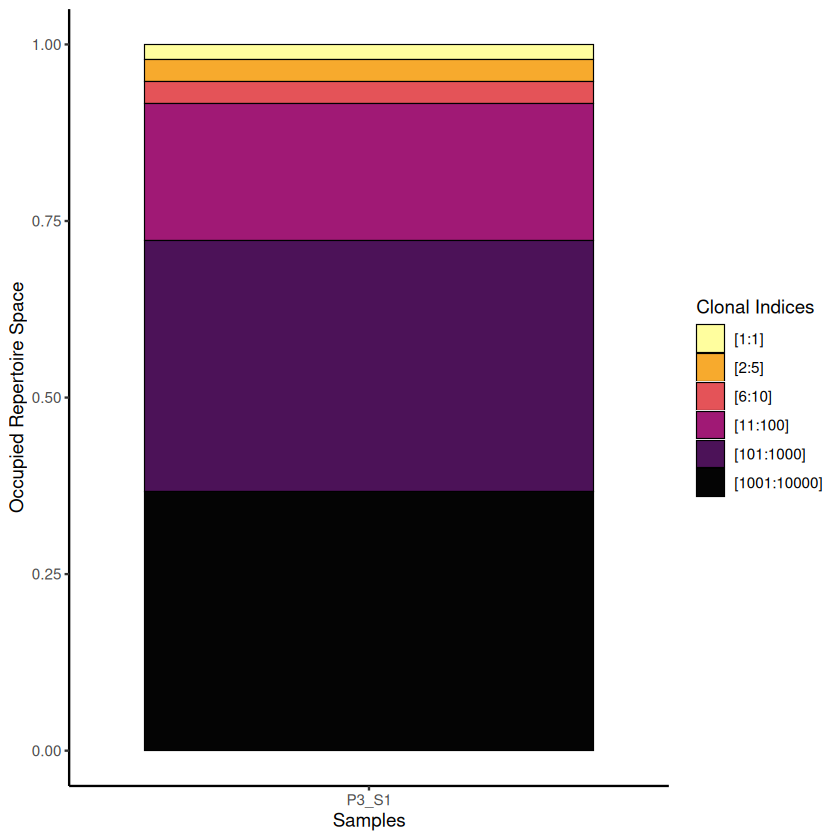

In [9]:
clonalProportion(combined.TCR_p3, 
                 cloneCall = "nt",
                 clonalSplit = c(1, 5, 10, 100, 1000, 10000)) 

## Clonal Bias

Smoothing formula not specified. Using: y ~ qss(x, lambda = 3)
Warning message in rq.fit.sfn(x, y, tau = tau, rhs = rhs, control = control, ...):
“tiny diagonals replaced with Inf when calling blkfct
”


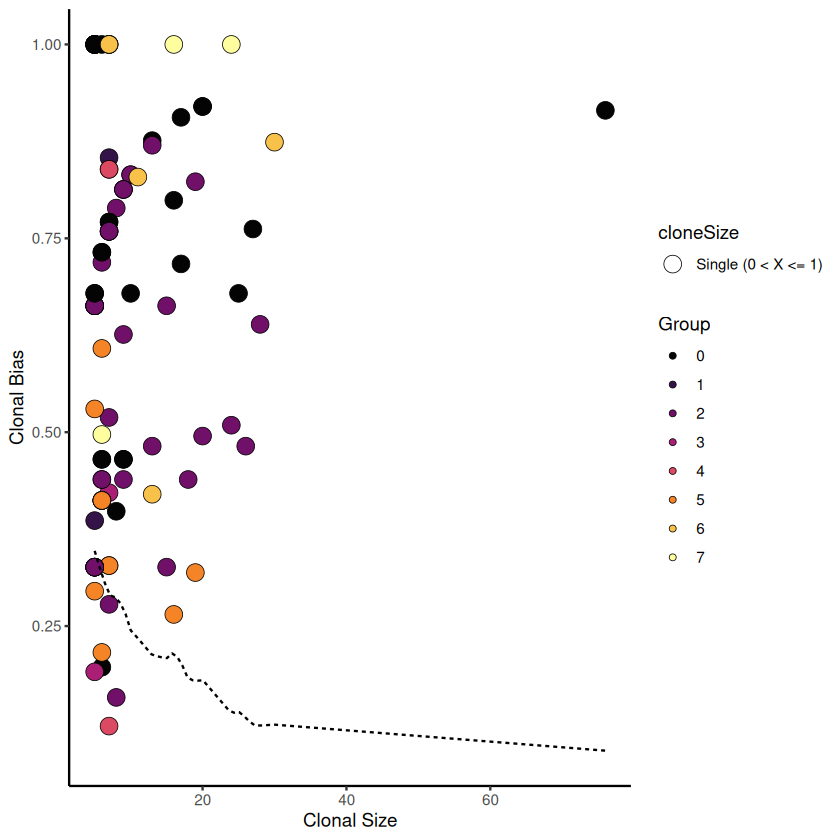

In [10]:
clonalBias(sce_all_patients_new, 
           cloneCall = "aa", 
           split.by = "orig.ident", 
           group.by = "seurat_clusters",
           n.boots = 10, 
           min.expand =5)

## Clonal Diversity

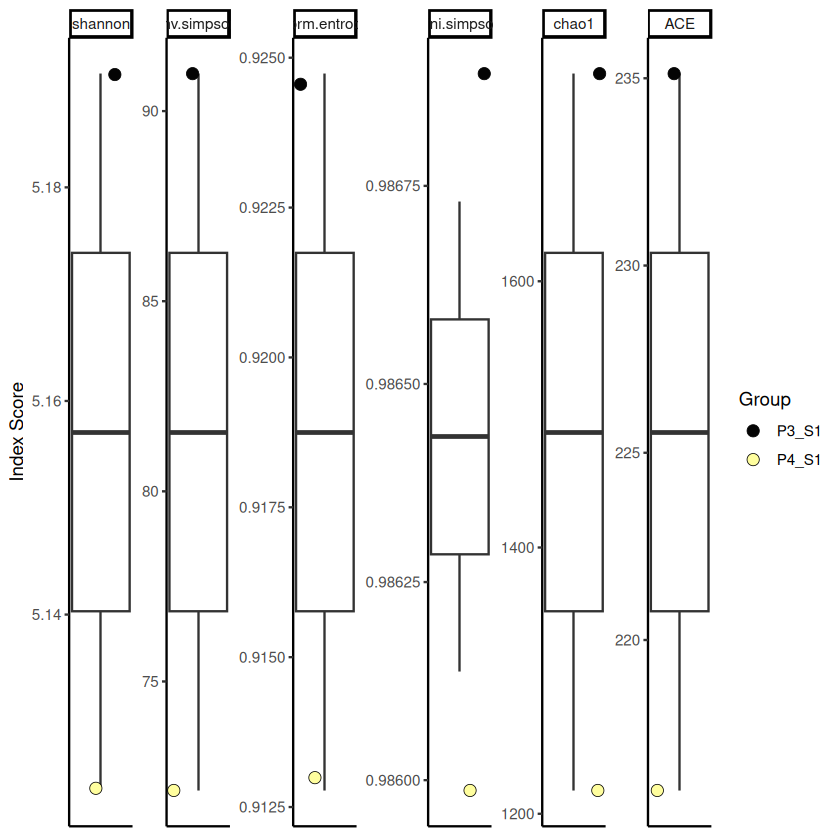

In [11]:
# High diversity indicates a polyclonal population; low diversity - clonal expansion eg in cancer.
clonalDiversity(combined.TCR_all, 
                cloneCall = "gene")
# higher diversity in patient3 across all diversity indices which is obvio.

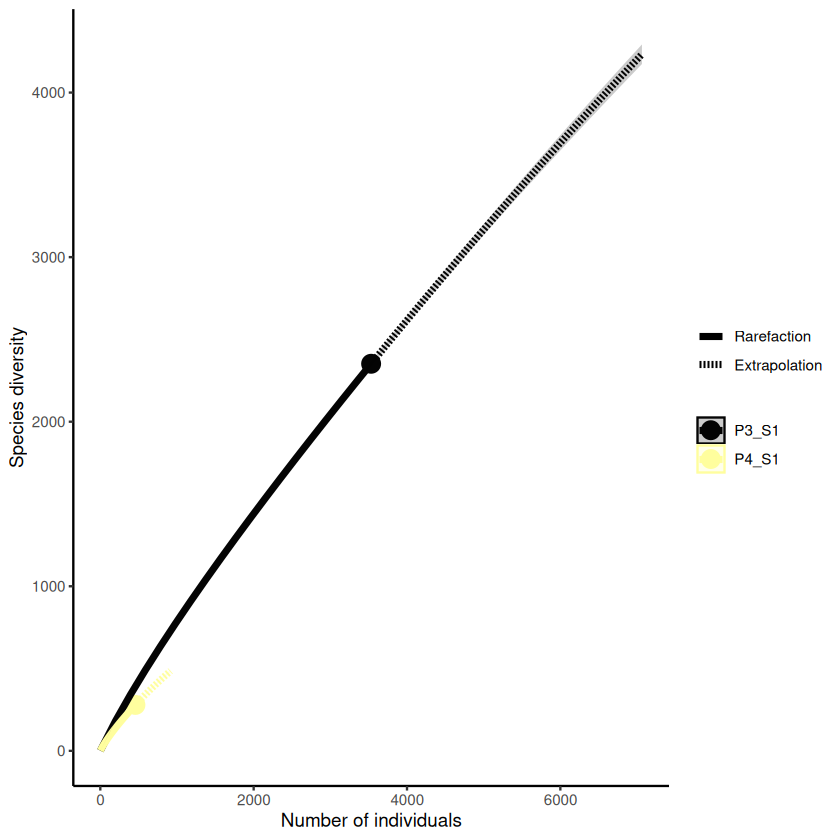

In [12]:
# how many unique TCR/BCR clones you’d expect as a function of seq. depth
## compare clonal richness between samples
clonalRarefaction(combined.TCR_all,
                  plot.type = 1,
                  hill.numbers = 0,
                  n.boots = 2)

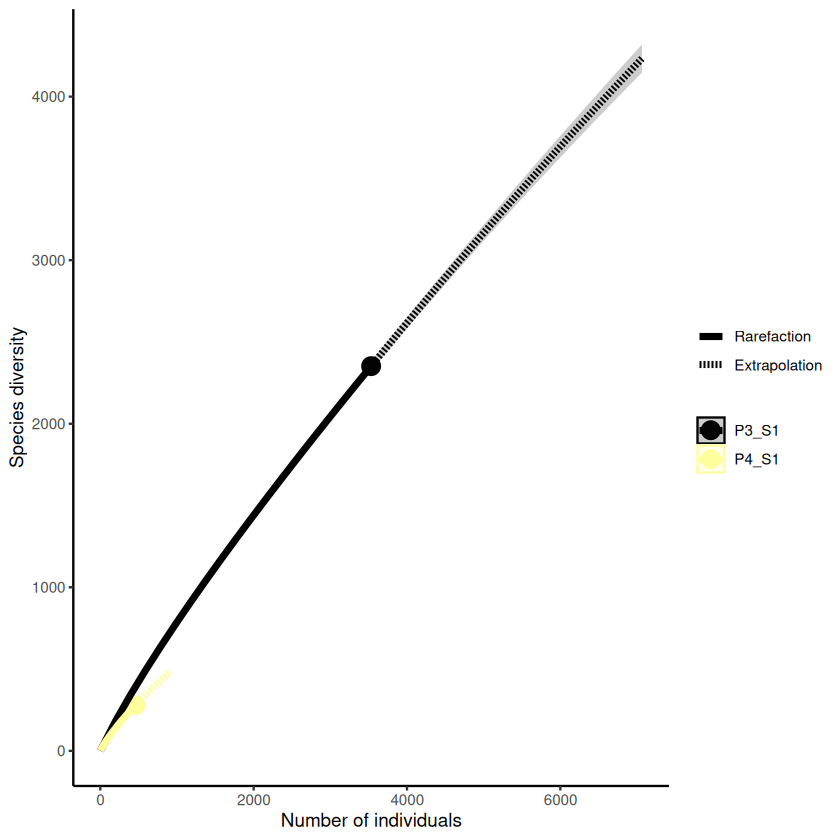

In [13]:
clonalRarefaction(combined.TCR_all,
                  plot.type = 1,
                  hill.numbers = 0,
                  n.boots = 2)

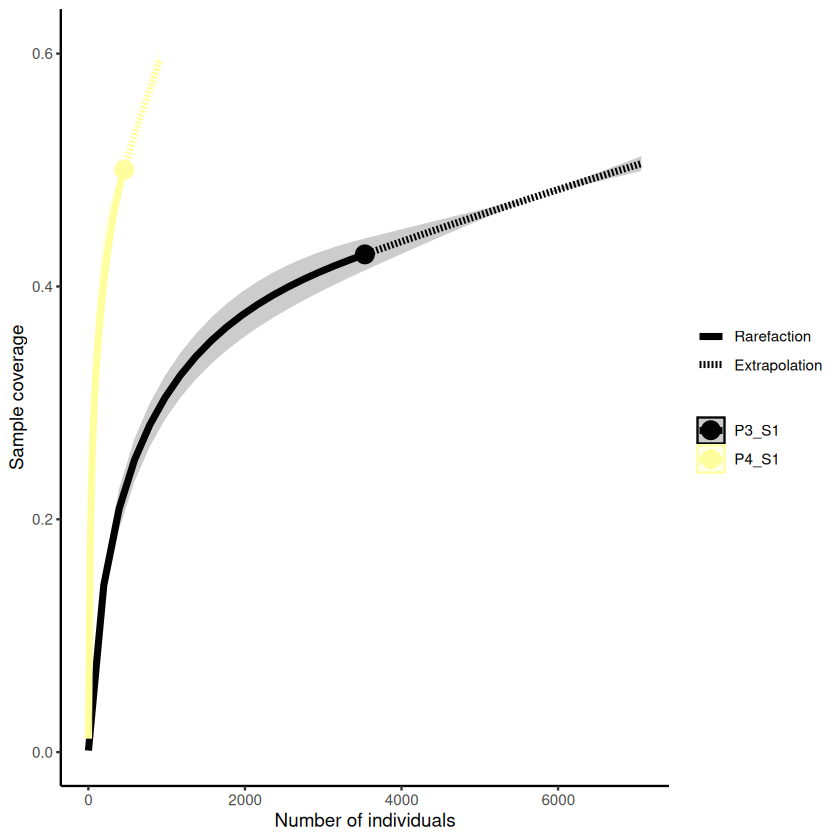

In [14]:
clonalRarefaction(combined.TCR_all,
                  plot.type = 2,
                  hill.numbers = 0,
                  n.boots = 2)

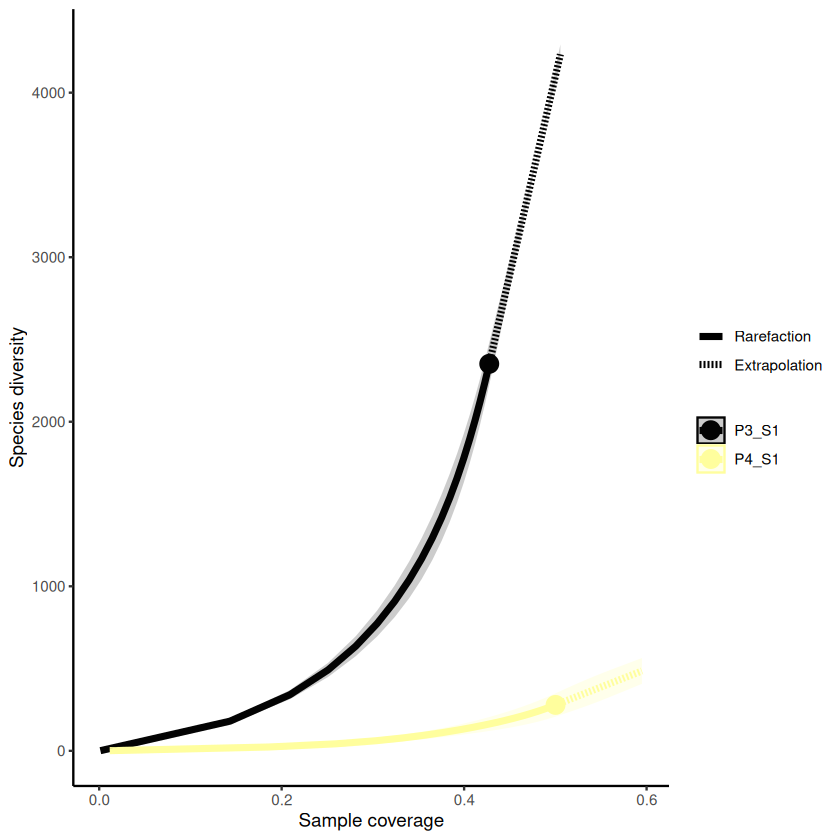

In [15]:
# this is the coverage based rarefaction+extrapol; diversity at equal sampling effort - fair sampling
clonalRarefaction(combined.TCR_all,
                  plot.type = 3,
                  hill.numbers = 0,
                  n.boots = 2)

In [16]:
# Patient 3 can be sampled morre

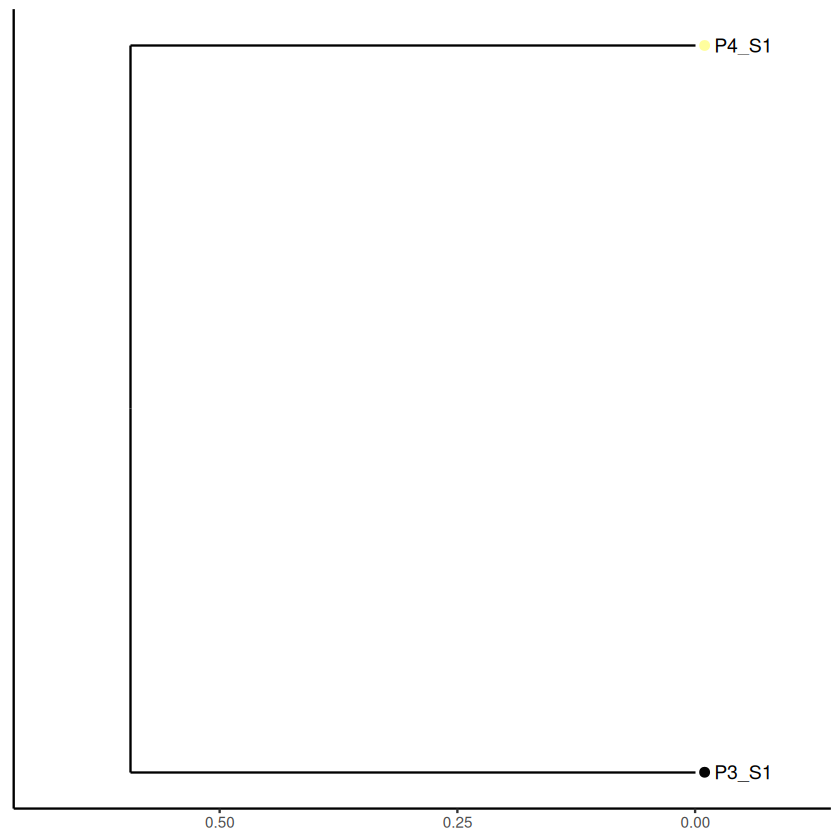

In [17]:
clonalSizeDistribution(combined.TCR_all, 
                       cloneCall = "aa", 
                       method= "ward.D2")

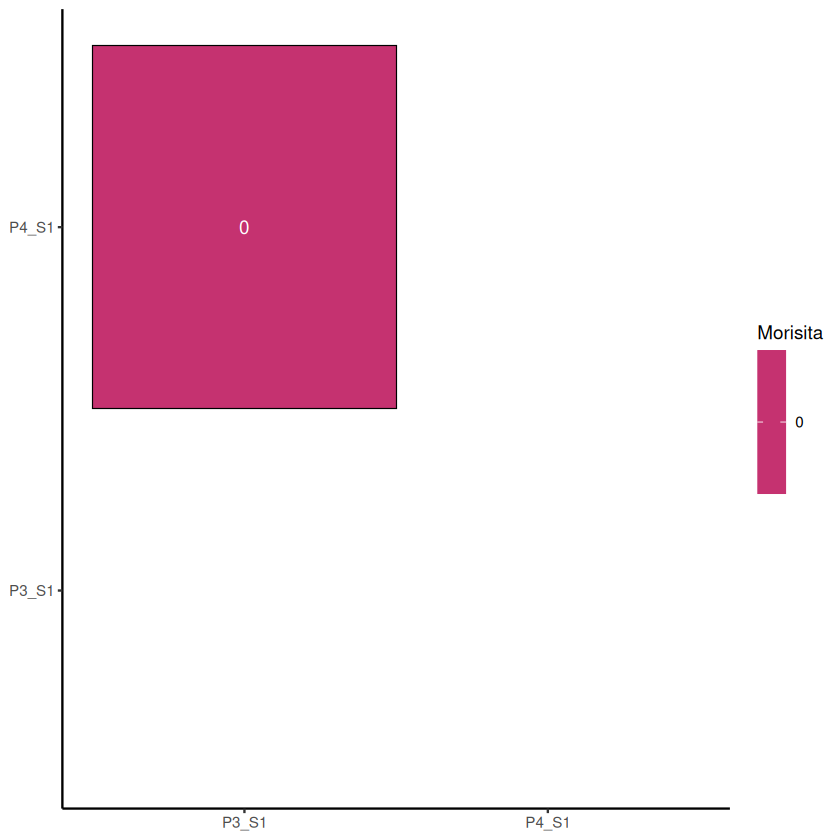

In [18]:
# clonal overlap to find similarity; corr. matrix
clonalOverlap(combined.TCR_all, 
              cloneCall = "strict", 
              method = "morisita")

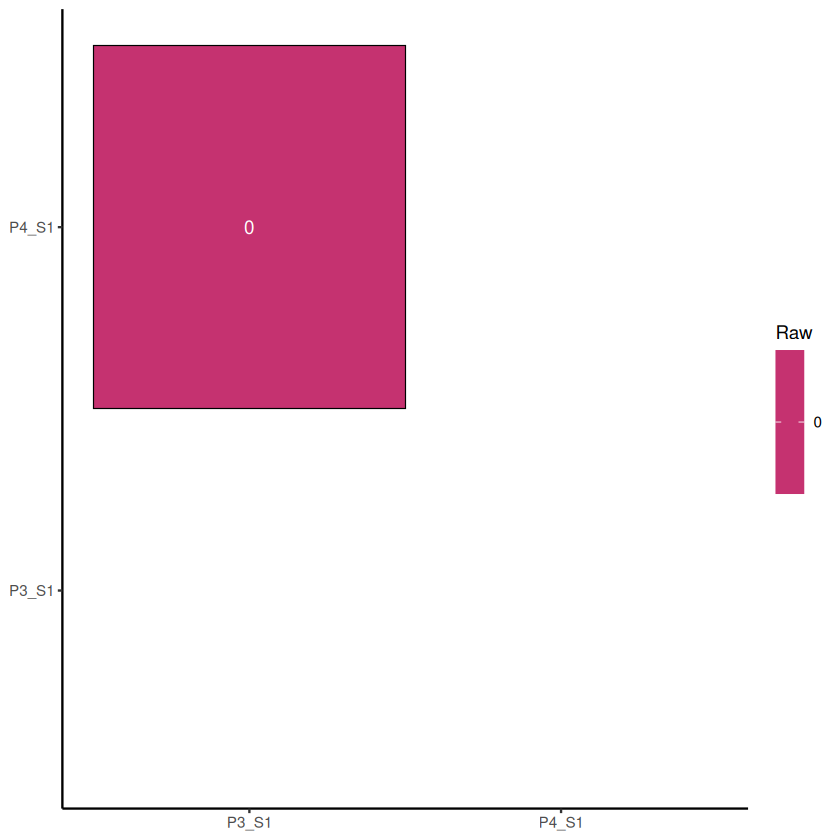

In [19]:
clonalOverlap(combined.TCR_all, 
              cloneCall = "strict", 
              method = "raw")

### Combining clones

In [20]:
# Check the first 10 variable features before removal
VariableFeatures(merged_seurat)[1:10]

[1] "CCL4"     "GNLY"     "HSPA1B"   "HSPA6"    "HSPA1A"   "HLA-DRA" 
 [7] "CXCL13"   "HLA-DRB1" "XCL1"     "CD74"

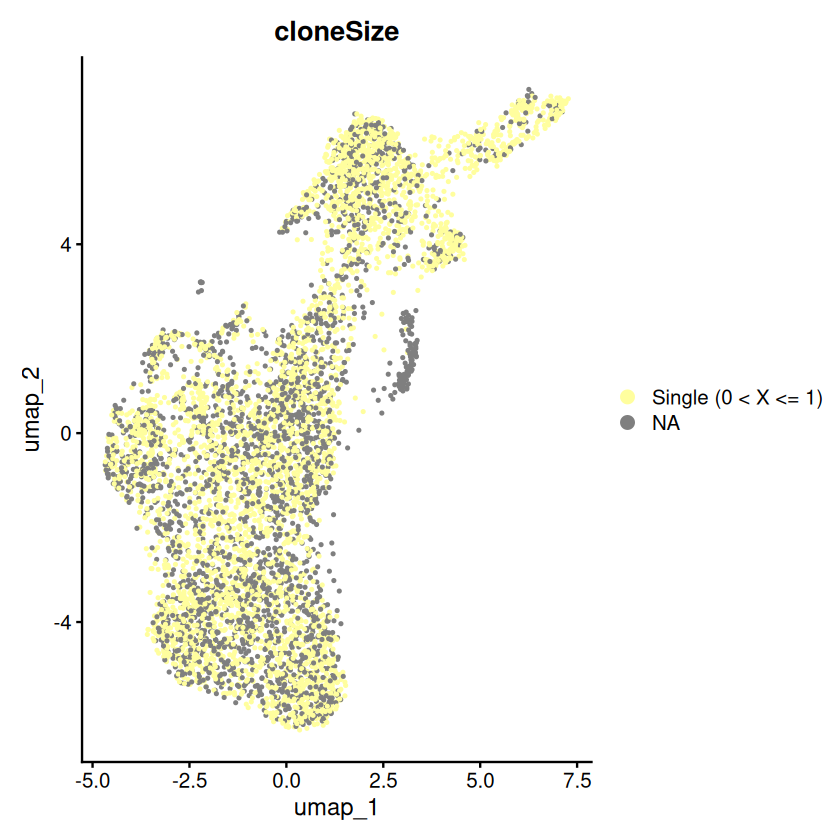

In [21]:
#Define color palette 
colorblind_vector <- hcl.colors(n=7, palette = "inferno", fixup = TRUE)

Seurat::DimPlot(sce_all_patients_new, group.by = "cloneSize") +
    scale_color_manual(values=rev(colorblind_vector[c(1,3,4,5,7)]))

In [22]:
# What's wrong with clone size calc!??

## From the vignette - Visualizations for Single-Cell Objects
#### func: clonalOverlay, clonalNetwork, clonalOccupy, alluvialClones & getCirclize

#### Clonal overlay

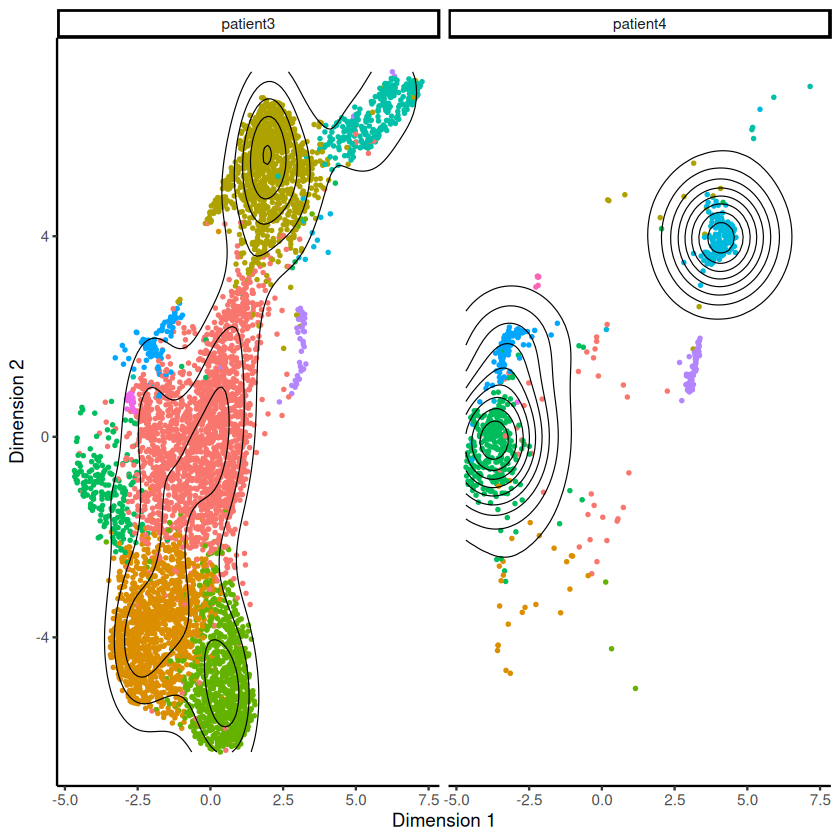

In [23]:
# overlays density contours to show where expanded clones are located in transcriptional space
clonalOverlay(sce_all_patients_new, 
              reduction = "umap", 
              cutpoint = 1, 
              bins = 10, 
              facet.by = "orig.ident") + 
              guides(color = "none")
# In pat3 clonal expansion span multiple transcriptional states. pat4 - localized expansion (due to less data probably)

In [24]:
sce_all_patients_new

An object of class Seurat 
45180 features across 6489 samples within 2 assays 
Active assay: RNA (23874 features, 2000 variable features)
 5 layers present: counts.patient3, counts.patient4, data.patient3, data.patient4, scale.data
 1 other assay present: SCT
 4 dimensional reductions calculated: pca, pca.rna, integrated.rpca, umap

#### Clonal network

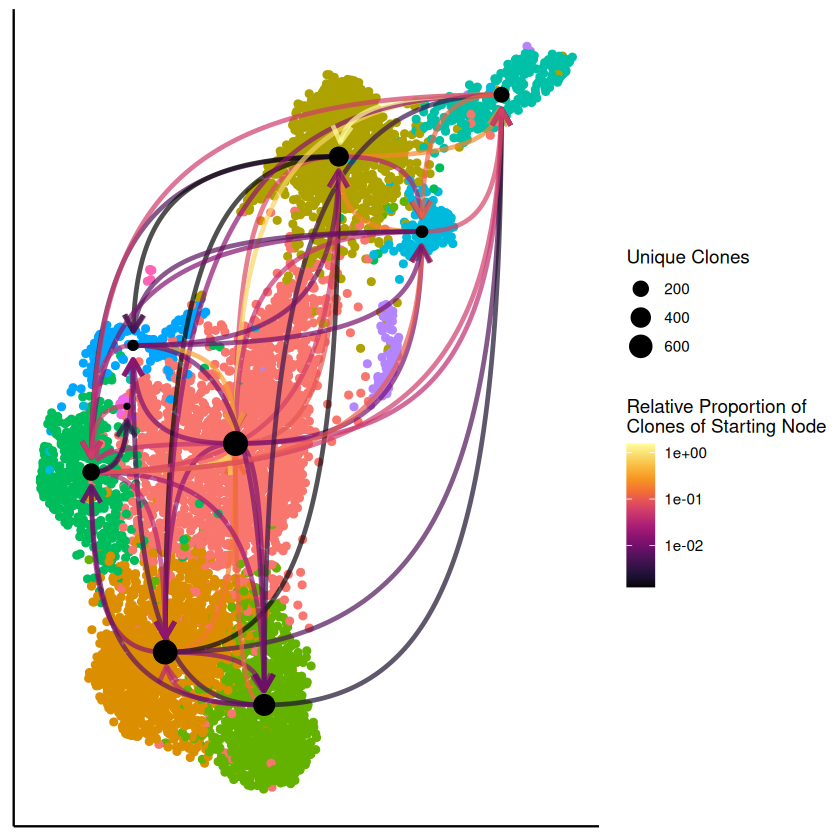

In [47]:
#ggraph needs to be loaded due to issues with ggplot
library(ggraph)

#No Identity filter
clonalNetwork(sce_all_patients_new, 
              reduction = "umap", 
              group.by = "seurat_clusters",
              filter.clones = NULL,
              filter.identity = NULL,
              cloneCall = "aa")

# directional clone flow
## high magnitude black lines are few, could be meaningful
### transcriptional flexibility
#### clonal hubs - large dots?

#### clonal occupy

clone size prob.

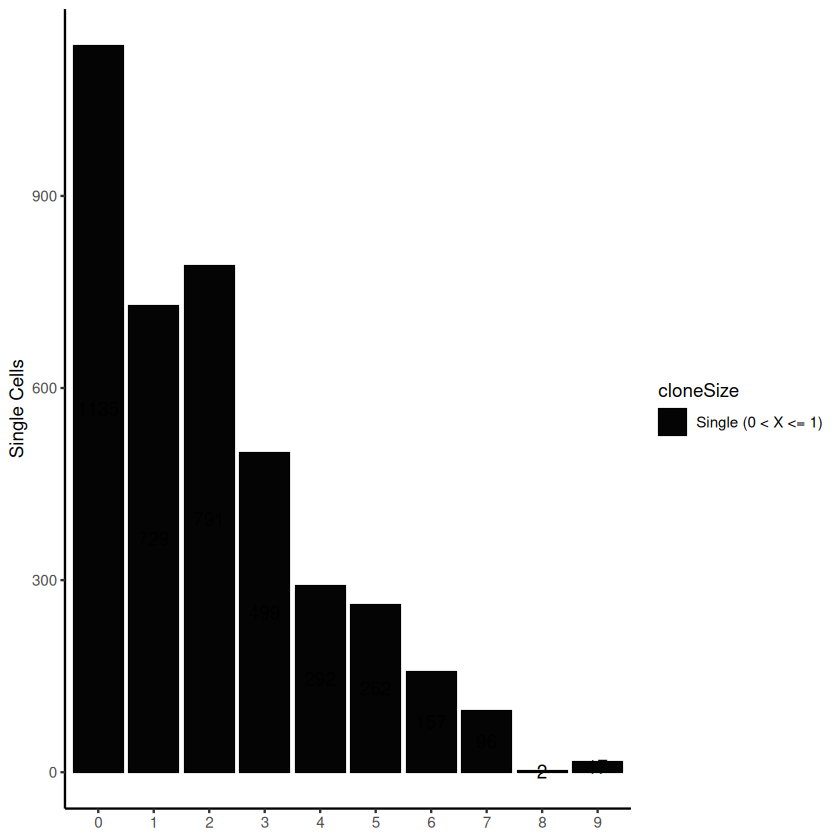

In [26]:
clonalOccupy(sce_all_patients_new, 
              x.axis = "seurat_clusters")

#### Chord diagrams

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




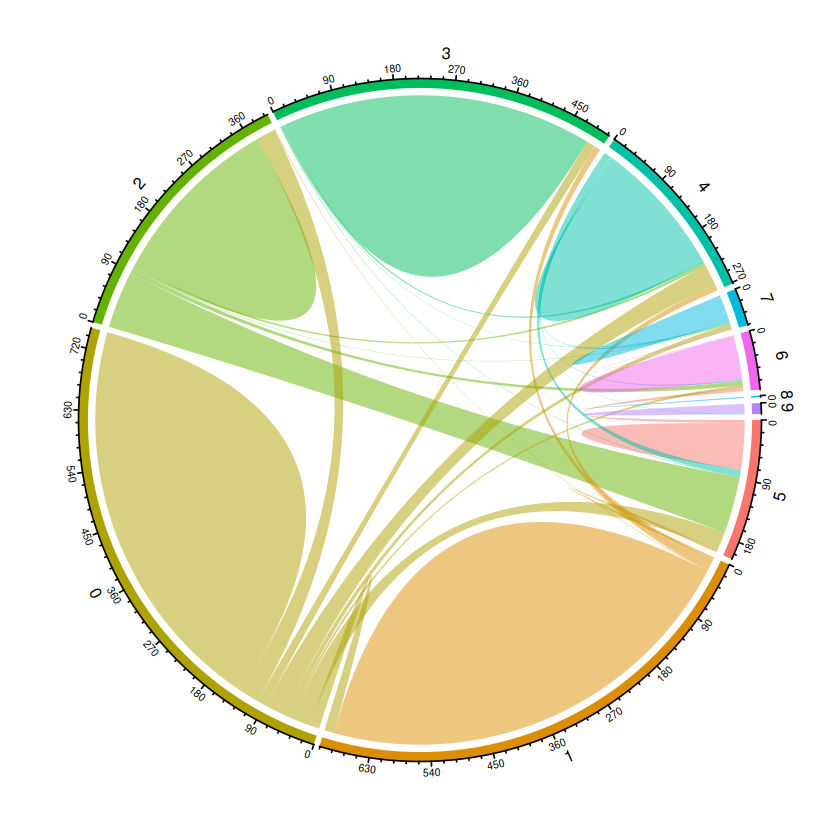

In [27]:
library(circlize)
library(scales)

circles <- getCirclize(sce_all_patients_new, 
                       group.by = "seurat_clusters")

#Just assigning the normal colors to each cluster
grid.cols <- hue_pal()(length(unique(sce_all_patients_new$seurat_clusters)))
names(grid.cols) <- unique(sce_all_patients_new$seurat_clusters)

#Graphing the chord diagram
chordDiagram(circles, self.link = 1, grid.col = grid.cols)

# clone sharing b/w cluster 2 and 5

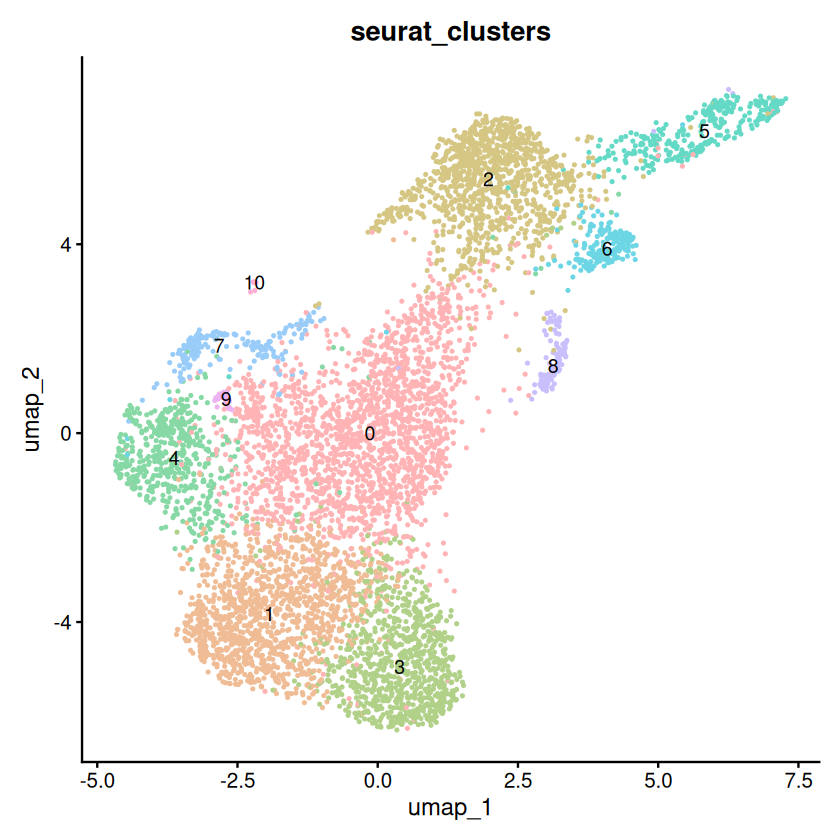

In [44]:
DimPlot(sce_all_patients_new, group.by = "seurat_clusters", label = T) +
  scale_color_manual(values = hcl.colors(n = length(unique(sce_all_patients_new@meta.data[,"seurat_clusters"])), "Set 3")) +
  NoLegend()

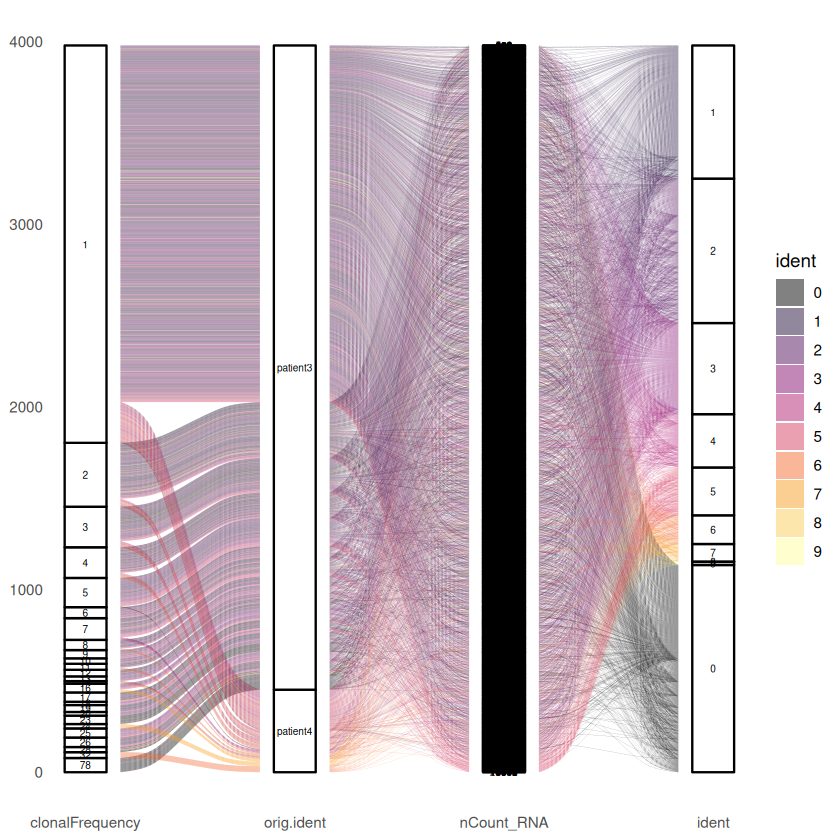

In [28]:
# just testing, no biological point
alluvialClones(sce_all_patients_new, 
                   cloneCall = "gene", 
                   y.axes = c("clonalFrequency", "orig.ident", "nCount_RNA"), 
                   color = "ident") 

## Clustering sequences

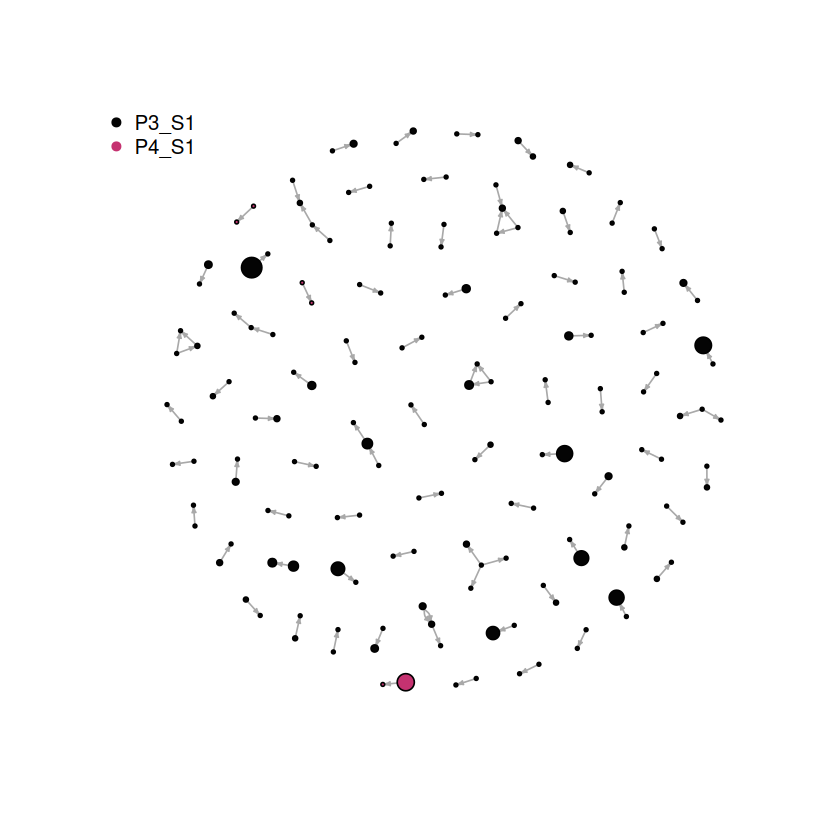

In [29]:
#igraph
##Clustering Patient samples
igraph.object <- clonalCluster(combined.TCR_all,
                               chain = "TRB",
                               sequence = "aa",
                               group.by = "sample",
                               threshold = 0.85, 
                               exportGraph = TRUE)

#Setting color scheme
col_legend <- factor(igraph::V(igraph.object)$group)
col_samples <- hcl.colors(3,"inferno")[as.numeric(col_legend)]
color.legend <- factor(unique(igraph::V(igraph.object)$group))

#Plotting
plot(
  igraph.object,
  vertex.size     = sqrt(igraph::V(igraph.object)$size),
  vertex.label    = NA,
  edge.arrow.size = .25,
  vertex.color    = col_samples
)
legend("topleft", legend = levels(color.legend), pch = 16, col = unique(col_samples), bty = "n")

# Each node is a unique TCR sequence, and edges connect similar sequences
## here no shared TCRs between patients, no major convergence - Potentially due to low data

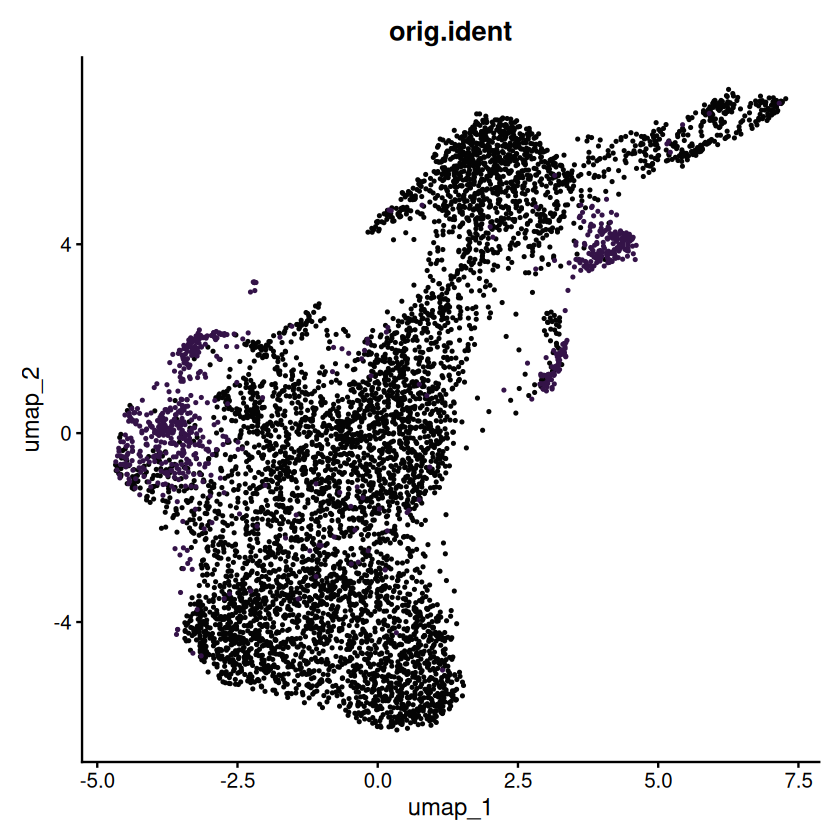

In [30]:
#Define color palette 
colorblind_vector <- hcl.colors(n=7, palette = "inferno", fixup = TRUE)

DimPlot(sce_all_patients_new, group.by = "orig.ident") +
    scale_color_manual(values =  hcl.colors(n=length(unique(scRep_example@meta.data[,"orig.ident"])), "inferno")) + 
  NoLegend()

In [31]:
colnames(sce_all_patients_new@meta.data)

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "CTgene"           "CTnt"            
 [9] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[13] "cloneSize"        "RNA_snn_res.0.5"  "seurat_clusters"

In [41]:
table(sce_all_patients_new$seurat_clusters)


   0    1    2    3    4    5    6    7    8    9   10 
1952 1257 1089  849  515  303  193  192  106   25    8 

##### SingleR for annotation

In [32]:
install.packages(c("curl", "data.table", "reticulate", "uwot", "jsonlite", "ps", "processx", "tinytex", "xfun", "zoo"))
BiocManager::install(c("BiocParallel", "DOSE", "R.utils", "VGAM", "ggnewscale"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://p3m.dev/cran/__linux__/noble/2025-02-27

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'BiocParallel' 'DOSE' 'R.utils' 'VGAM'
  'ggnewscale'”


In [33]:
BiocManager::install("SingleR", dependencies = TRUE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://p3m.dev/cran/__linux__/noble/2025-02-27

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'SingleR'

also installing the dependencies ‘alabaster.ranges’, ‘alabaster.base’, ‘alabaster.matrix’, ‘alabaster.sce’, ‘alabaster.se’, ‘scRNAseq’, ‘celldex’


Warning message in install.packages(...):
“installation of package ‘alabaster.base’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘SingleR’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘alabaster.ranges’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘alabaster.matrix’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘alabaster.se’ had non-zero 

In [34]:
library(SingleR)
library(SummarizedExperiment)
library(celldex)

# Load reference
ref <- celldex::HumanPrimaryCellAtlasData()

# Your single-cell expression matrix
# Assuming 'sce' is a SingleCellExperiment object
pred <- SingleR(test = sce, ref = ref, labels = ref$label.main)

# Add labels to metadata
colData(sce)$SingleR_labels <- pred$labels

ERROR: Error in library(SingleR): there is no package called ‘SingleR’
